# LADA v5: Sistema de Recomendacion Multinivel Optimizado

## Descripcion
Copia exacta de la metodologia de v4 (Level 1 propagation + progressive fallback)
con las siguientes correcciones:
- **Bug fix**: `range(1)` → `range(10)` en Random Search (v4 solo buscaba 1 iteracion)
- **Bug fix**: `sample(n=2000)` → `PCT_TEST_EVALUAR` configurable (v4 solo evaluaba 2000 casos)
- **Optimizacion**: Pre-computo de dicts numpy para lookup O(1) en vez de filtrado DataFrame O(n)
- **Pipeline corregido**: 7 fixes de data pipeline aplicados (parquet names, column names, type casts, etc.)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import skfuzzy as fuzz
import random
import time
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import math
print('Imports completados')

Imports completados


In [2]:
# Cargar los 6 datasets
DATA_PATH = '../data/'

df_materias = pd.read_parquet(f'{DATA_PATH}historial_materias_estudiante_anonymized.parquet')
print(f' Historial de materias: {df_materias.shape[0]:,} registros, {df_materias.shape[1]} columnas')

df_rendimiento = pd.read_parquet(f'{DATA_PATH}historial_rendimiento_academico_estudiante_anonymized.parquet')
print(f' Rendimiento academico: {df_rendimiento.shape[0]:,} registros, {df_rendimiento.shape[1]} columnas')

df_percentiles = pd.read_parquet(f'{DATA_PATH}percentiles_academicos_estudiante_anonymized.parquet')
print(f' Percentiles academicos: {df_percentiles.shape[0]:,} registros, {df_percentiles.shape[1]} columnas')

df_info_actual = pd.read_parquet(f'{DATA_PATH}informacion_actual_estudiante_anonymized.parquet')
print(f' Informacion actual: {df_info_actual.shape[0]:,} registros, {df_info_actual.shape[1]} columnas')

df_riesgos = pd.read_parquet(f'{DATA_PATH}riesgos_historicos_estudiante_pregrado_anonymized.parquet')
print(f' Riesgos historicos: {df_riesgos.shape[0]:,} registros, {df_riesgos.shape[1]} columnas')

df_facultades_departamentos = pd.read_parquet(f'{DATA_PATH}oferta_academica_anonymized.parquet')
print(f' Oferta Academica: {df_facultades_departamentos.shape[0]:,} registros, {df_facultades_departamentos.shape[1]} columnas')

 Historial de materias: 4,931,740 registros, 15 columnas
 Rendimiento academico: 611,654 registros, 22 columnas
 Percentiles academicos: 158,429 registros, 11 columnas
 Informacion actual: 222,407 registros, 30 columnas
 Riesgos historicos: 369,370 registros, 12 columnas
 Oferta Academica: 334,547 registros, 5 columnas


In [3]:
# ============================================================================
# PREPROCESAMIENTO DE MATERIAS
# ============================================================================
print('1. Procesando historial de materias...')

df_materias_clean = df_materias[
    (df_materias['NIVEL_ACADEMICO_ESTUDIANTE'] == 'Pregrado') &
    (df_materias['ESTATUS'] == 'HISTORIA') &
    (df_materias['RESULTADO'].isin(['APROBADO', 'REPROBADO', 'RETIRADO']))
].assign(
    EXITO=lambda x: (x['RESULTADO'] == 'APROBADO').astype('int8'),
    CODIGO_CURSO=lambda x: x['CODIGO_CURSO'].astype(str),
    PERIODO=lambda x: x['PERIODO'].astype(str)
)

# Deduplicar facultades por (CODIGO_CURSO, PERIODO)
df_facultades_clean = df_facultades_departamentos[
    ['CODIGO_CURSO', 'PERIODO', 'CODIGO_DEPARTAMENTO', 'CODIGO_FACULTAD']
].drop_duplicates(subset=['CODIGO_CURSO', 'PERIODO'], keep='first').astype({
    'CODIGO_CURSO': str,
    'PERIODO': str
})

# Merge por curso y periodo
df_materias_clean = df_materias_clean.merge(
    df_facultades_clean,
    on=['CODIGO_CURSO', 'PERIODO'],
    how='left',
    validate='m:1'
)

print(f'   Registros originales: {len(df_materias):,}')
print(f'   Registros despues de filtrado: {len(df_materias_clean):,}')
print(f'   Tasa de exito general: {df_materias_clean["EXITO"].mean()*100:.2f}%')
print(f'   Cursos con departamento: {df_materias_clean["CODIGO_DEPARTAMENTO"].notna().sum():,} ({df_materias_clean["CODIGO_DEPARTAMENTO"].notna().mean()*100:.1f}%)')

# ============================================================================
# PREPROCESAMIENTO DE RENDIMIENTO
# ============================================================================
print('\n2. Procesando rendimiento academico...')
df_rendimiento_clean = df_rendimiento[
    (df_rendimiento['PGA'].between(0, 5)) &
    (df_rendimiento['PORCENTAJE_CREDITOS_APROBADOS'].between(0, 100))
].copy()

print(f'   Registros originales: {len(df_rendimiento):,}')
print(f'   Registros despues de limpieza: {len(df_rendimiento_clean):,}')
print(f'   PGA promedio: {df_rendimiento_clean["PGA"].mean():.2f}')

# ============================================================================
# RIESGOS - usar solo las 5 columnas binarias especificas
# ============================================================================
print('\n3. Procesando indicadores de riesgo...')
df_riesgos_clean = df_riesgos.copy()

risk_binary_cols = [
    'bajo_promedio_segundo_semestre',
    'bajo_promedio_tercer_semestre_o_mas',
    'bajo_promedio_movil',
    'no_lectura_ingles_sexto_semestre',
    'porcentaje_creditos_aprobados_menor_50'
]

risk_cols_disponibles = [col for col in risk_binary_cols if col in df_riesgos_clean.columns]

if risk_cols_disponibles:
    for col in risk_cols_disponibles:
        df_riesgos_clean[col] = df_riesgos_clean[col].fillna(0).astype(int)
    df_riesgos_clean['RIESGO_SCORE'] = df_riesgos_clean[risk_cols_disponibles].sum(axis=1)
else:
    df_riesgos_clean['RIESGO_SCORE'] = 0

print(f'   Columnas de riesgo encontradas: {len(risk_cols_disponibles)}/{len(risk_binary_cols)}')
print(f'   Score de riesgo promedio: {df_riesgos_clean["RIESGO_SCORE"].mean():.2f}')

print('\nPreprocesamiento completado.')

1. Procesando historial de materias...
   Registros originales: 4,931,740
   Registros despues de filtrado: 3,624,475
   Tasa de exito general: 93.77%
   Cursos con departamento: 3,624,358 (100.0%)

2. Procesando rendimiento academico...
   Registros originales: 611,654
   Registros despues de limpieza: 611,654
   PGA promedio: 3.97

3. Procesando indicadores de riesgo...
   Columnas de riesgo encontradas: 5/5
   Score de riesgo promedio: 1.04

Preprocesamiento completado.


In [4]:

# ============================================================================
# FILTRO DE PERIODOS NO ESTÁNDAR
# Excluir periodos cuyo código no corresponde a ningún tipo académico
# documentado en el calendario de Uniandes. Solo se conservan periodos con
# orden cronológico inequívoco para garantizar la integridad del split temporal.
# Sufijos válidos: 10 (sem 1), 20 (sem 2), 18 (verano), 19 (intersemestral),
#                  11-15 (ciclos posgrado).
# ============================================================================

def clasificar_periodo(periodo):
    periodo_str = str(periodo)
    if len(periodo_str) != 6:
        return 'especial'
    sufijo = periodo_str[-2:]
    if sufijo == '10':
        return 'semestre_1'
    elif sufijo == '20':
        return 'semestre_2'
    elif sufijo == '18':
        return 'verano'
    elif sufijo == '19':
        return 'intersemestral'
    elif sufijo in ['11', '12', '13', '14', '15']:
        return 'ciclo_posgrado'
    else:
        return 'especial'

n_antes_mat = len(df_materias_clean)
df_materias_clean['TIPO_PERIODO'] = df_materias_clean['PERIODO'].apply(clasificar_periodo)
df_materias_clean = df_materias_clean[df_materias_clean['TIPO_PERIODO'] != 'especial'].copy()

n_antes_rend = len(df_rendimiento_clean)
df_rendimiento_clean['TIPO_PERIODO'] = df_rendimiento_clean['PERIODO'].apply(clasificar_periodo)
df_rendimiento_clean = df_rendimiento_clean[df_rendimiento_clean['TIPO_PERIODO'] != 'especial'].copy()

print(f'Materias: {n_antes_mat:,} → {len(df_materias_clean):,} (eliminados: {n_antes_mat - len(df_materias_clean):,})')
print(f'Rendimiento: {n_antes_rend:,} → {len(df_rendimiento_clean):,} (eliminados: {n_antes_rend - len(df_rendimiento_clean):,})')


Materias: 3,624,475 → 3,624,426 (eliminados: 49)
Rendimiento: 611,654 → 611,633 (eliminados: 21)


In [5]:
# ============================================================================
# CONSTRUCCION DE NIVELES JERARQUICOS
# ============================================================================
usar_departamento_nivel2 = True

print('Procesando inscripciones por semestre...')

# Agrupar materias por estudiante y periodo
df_inscripciones = df_materias_clean.groupby(['CODIGO_ESTUDIANTE', 'PERIODO'], as_index=False).agg({
    'CODIGO_CURSO': list,
    'NUMERO_CREDITOS': ['sum', 'count'],
    'EXITO': 'mean'
})

# Aplanar nombres de columnas
df_inscripciones.columns = ['CODIGO_ESTUDIANTE', 'PERIODO', 'CURSOS_LISTA',
                             'CREDITOS_TOTALES', 'NUM_CURSOS', 'TASA_EXITO']

print(f'  Procesados {len(df_inscripciones):,} semestres de inscripciones')

# NIVEL 1: Numero total de cursos
print('\nConstruyendo Nivel 1 (Numero total de cursos)...')
df_inscripciones['NIVEL_1'] = df_inscripciones['NUM_CURSOS'].astype(str)
print(f'Distribucion Nivel 1:')
print(df_inscripciones['NIVEL_1'].value_counts().head(10))

# PREPARAR MAPEO: Crear diccionario curso -> categoria UNA SOLA VEZ
print(f'\nPreparando mapeo curso -> categoria...')
col_categoria = 'CODIGO_DEPARTAMENTO' if usar_departamento_nivel2 else 'CODIGO_FACULTAD'
prefijo = 'DEPT_' if usar_departamento_nivel2 else 'FAC_'

# Mapeo eficiente: curso -> categoria (identico al v4)
mapeo_curso_cat = df_facultades_departamentos.drop_duplicates(subset=['CODIGO_CURSO']).set_index('CODIGO_CURSO')[col_categoria].to_dict()

# Rellenar con 'DESCONOCIDO' para cursos no encontrados o NaN
mapeo_curso_cat = {k: f"{prefijo}{v}" if pd.notna(v) else 'DESCONOCIDO'
                   for k, v in mapeo_curso_cat.items()}

# NIVEL 2: Numero de cursos por categoria
print(f'\nConstruyendo Nivel 2 (usando {"DEPARTAMENTO" if usar_departamento_nivel2 else "FACULTAD"})...')

def construir_nivel_2(cursos_lista):
    categorias = [mapeo_curso_cat.get(str(curso), 'DESCONOCIDO') for curso in cursos_lista]
    contador = pd.Series(categorias).value_counts().to_dict()
    firma = '_'.join([f"{cat}:{count}" for cat, count in sorted(contador.items())])
    return firma

df_inscripciones['NIVEL_2'] = df_inscripciones['CURSOS_LISTA'].apply(construir_nivel_2)
print(f'Categorias unicas en Nivel 2: {df_inscripciones["NIVEL_2"].nunique():,}')

# NIVEL 3: Codigos especificos de cursos
print('\nConstruyendo Nivel 3 (Codigos especificos de cursos)...')

df_inscripciones['NIVEL_3'] = df_inscripciones['CURSOS_LISTA'].apply(
    lambda x: '_'.join(sorted([str(c) for c in x]))
)
print(f'Combinaciones unicas en Nivel 3: {df_inscripciones["NIVEL_3"].nunique():,}')

print(f'\nNIVELES CONSTRUIDOS - NIVEL_2 usa: {"DEPARTAMENTO" if usar_departamento_nivel2 else "FACULTAD"}')

Procesando inscripciones por semestre...
  Procesados 698,410 semestres de inscripciones

Construyendo Nivel 1 (Numero total de cursos)...
Distribucion Nivel 1:
NIVEL_1
6     178947
7     114850
5     110205
1      85503
8      54032
3      42511
4      42135
2      38108
9      20652
10      7648
Name: count, dtype: int64

Preparando mapeo curso -> categoria...

Construyendo Nivel 2 (usando DEPARTAMENTO)...
Categorias unicas en Nivel 2: 234,407

Construyendo Nivel 3 (Codigos especificos de cursos)...
Combinaciones unicas en Nivel 3: 534,808

NIVELES CONSTRUIDOS - NIVEL_2 usa: DEPARTAMENTO


In [6]:
# ============================================================================
# CALCULO DE PGA_ANTERIOR (prevencion de data leakage)
# ============================================================================
def calcular_pga_anterior(df_inscripciones, df_rendimiento, df_info_actual):
    print('Calculando PGA_ANTERIOR...')
    df_ins = df_inscripciones[['CODIGO_ESTUDIANTE', 'PERIODO']].copy()
    
    df_hist = df_rendimiento[[
        'CODIGO_ESTUDIANTE', 'PERIODO', 'PGA',
        'TOTAL_SEMESTRES_MATRICULADOS', 'PORCENTAJE_CREDITOS_APROBADOS'
    ]].copy()
    df_hist['PGA'] = pd.to_numeric(df_hist['PGA'], errors='coerce')
    df_hist['TOTAL_SEMESTRES_MATRICULADOS'] = pd.to_numeric(df_hist['TOTAL_SEMESTRES_MATRICULADOS'], errors='coerce')
    df_hist['PORCENTAJE_CREDITOS_APROBADOS'] = pd.to_numeric(df_hist['PORCENTAJE_CREDITOS_APROBADOS'], errors='coerce')
    
    pct_creditos_promedio = df_hist['PORCENTAJE_CREDITOS_APROBADOS'].mean()
    print(f'  Promedio general de % creditos aprobados: {pct_creditos_promedio:.2f}%')
    
    df_hist = df_hist.rename(columns={
        'PERIODO': 'PERIODO_HIST', 'PGA': 'PGA_HIST',
        'TOTAL_SEMESTRES_MATRICULADOS': 'SEMESTRES_HIST',
        'PORCENTAJE_CREDITOS_APROBADOS': 'PCT_CREDITOS_HIST'
    })
    
    df_icfes = df_info_actual[['CODIGO_ESTUDIANTE', 'PUNTAJE_ICFES']].copy()
    df_icfes['PUNTAJE_ICFES'] = pd.to_numeric(df_icfes['PUNTAJE_ICFES'], errors='coerce')
    
    df_ins = df_ins.sort_values('PERIODO')
    df_hist = df_hist.sort_values('PERIODO_HIST')
    
    df_merged = pd.merge_asof(
        df_ins, df_hist,
        left_on='PERIODO', right_on='PERIODO_HIST',
        by='CODIGO_ESTUDIANTE',
        direction='backward',
        allow_exact_matches=False
    )
    
    df_final = pd.merge(df_merged, df_icfes, on='CODIGO_ESTUDIANTE', how='left')
    
    tiene_historia = df_final['PGA_HIST'].notna()
    tiene_icfes = df_final['PUNTAJE_ICFES'].notna()
    
    df_final['PGA_ANTERIOR'] = np.nan
    df_final['SEMESTRES_ANTERIORES'] = np.nan
    df_final['PCT_CREDITOS_ANTERIOR'] = np.nan
    df_final['FUENTE_PGA'] = 'SIN_DATOS'
    
    # Caso 1: Tiene historial
    df_final.loc[tiene_historia, 'PGA_ANTERIOR'] = df_final.loc[tiene_historia, 'PGA_HIST']
    df_final.loc[tiene_historia, 'SEMESTRES_ANTERIORES'] = df_final.loc[tiene_historia, 'SEMESTRES_HIST']
    df_final.loc[tiene_historia, 'PCT_CREDITOS_ANTERIOR'] = df_final.loc[tiene_historia, 'PCT_CREDITOS_HIST']
    df_final.loc[tiene_historia, 'PERIODO_FUENTE_PGA'] = df_final.loc[tiene_historia, 'PERIODO_HIST']
    df_final.loc[tiene_historia, 'FUENTE_PGA'] = 'PGA_HISTORICO'
    
    # Caso 2: No tiene historial, usa ICFES
    mask_icfes = (~tiene_historia) & (tiene_icfes)
    df_final.loc[mask_icfes, 'PGA_ANTERIOR'] = (df_final.loc[mask_icfes, 'PUNTAJE_ICFES'] / 500.0) * 5.0
    df_final.loc[mask_icfes, 'SEMESTRES_ANTERIORES'] = 0
    df_final.loc[mask_icfes, 'PCT_CREDITOS_ANTERIOR'] = pct_creditos_promedio
    df_final.loc[mask_icfes, 'FUENTE_PGA'] = 'ICFES_NORMALIZADO'
    
    print(f'  Con historial: {tiene_historia.sum():,}')
    print(f'  Con ICFES: {mask_icfes.sum():,}')
    print(f'  Sin datos: {(~tiene_historia & ~tiene_icfes).sum():,}')
    
    resultado = df_final[[
        'CODIGO_ESTUDIANTE', 'PERIODO', 'PGA_ANTERIOR',
        'SEMESTRES_ANTERIORES', 'PCT_CREDITOS_ANTERIOR',
        'PERIODO_FUENTE_PGA', 'FUENTE_PGA'
    ]].copy()
    
    return resultado

# CRITICO: Convertir PERIODO a int en todos los DataFrames antes de merge_asof
df_inscripciones['PERIODO'] = df_inscripciones['PERIODO'].astype(int)
df_rendimiento_clean['PERIODO'] = df_rendimiento_clean['PERIODO'].astype(int)
df_info_actual['PERIODO'] = df_info_actual['PERIODO'].astype(int)

resultado_pga = calcular_pga_anterior(df_inscripciones, df_rendimiento_clean, df_info_actual)

# Merge con inscripciones
df_inscripciones = df_inscripciones.merge(
    resultado_pga, on=['CODIGO_ESTUDIANTE', 'PERIODO'], how='left'
)

print(f'\nDistribucion de fuentes de PGA:')
print(df_inscripciones['FUENTE_PGA'].value_counts())

# Eliminar registros sin PGA_ANTERIOR
antes = len(df_inscripciones)
df_inscripciones = df_inscripciones.dropna(subset=['PGA_ANTERIOR']).copy()
print(f'\nRegistros totales: {antes:,}')
print(f'Registros con PGA valido: {len(df_inscripciones):,}')
print(f'Registros descartados (sin PGA ni ICFES): {antes - len(df_inscripciones):,}')
print(f'\nDataset final: {len(df_inscripciones):,} registros')

Calculando PGA_ANTERIOR...
  Promedio general de % creditos aprobados: 0.89%
  Con historial: 415,761
  Con ICFES: 31,669
  Sin datos: 250,980

Distribucion de fuentes de PGA:
FUENTE_PGA
PGA_HISTORICO        415761
SIN_DATOS            250980
ICFES_NORMALIZADO     31669
Name: count, dtype: int64

Registros totales: 698,410
Registros con PGA valido: 447,430
Registros descartados (sin PGA ni ICFES): 250,980

Dataset final: 447,430 registros


In [7]:
# ============================================================================
# SPLIT TEMPORAL
# ============================================================================
PERIODO_TRAIN_END = 202010
PERIODO_VAL_END = 202310

df_train = df_inscripciones[df_inscripciones['PERIODO'] <= PERIODO_TRAIN_END].copy()
df_val = df_inscripciones[
    (df_inscripciones['PERIODO'] > PERIODO_TRAIN_END) &
    (df_inscripciones['PERIODO'] <= PERIODO_VAL_END)
].copy()
df_test = df_inscripciones[df_inscripciones['PERIODO'] > PERIODO_VAL_END].copy()

print(f'TRAIN (<=202010): {len(df_train):,} registros')
print(f'VAL (202011-202310): {len(df_val):,} registros')
print(f'TEST (>202310): {len(df_test):,} registros')
print(f'Total: {len(df_train) + len(df_val) + len(df_test):,}')

TRAIN (<=202010): 285,158 registros
VAL (202011-202310): 90,019 registros
TEST (>202310): 72,253 registros
Total: 447,430


In [8]:
# ============================================================================
# FEATURES PARA CLUSTERING
# ============================================================================
FEATURE_COLS = ['PGA_ANTERIOR', 'SEMESTRES_ANTERIORES', 'PCT_CREDITOS_ANTERIOR',
                'NUM_CURSOS', 'CREDITOS_TOTALES']

# ============================================================================
# ESPACIOS DE HIPERPARAMETROS
# ============================================================================
PARAM_SPACES = {
    'fuzzy': {
        'n_clusters': [2, 3, 4, 5],
        'm': [1.5, 2.0, 2.5, 3.0],
        'error': [0.001, 0.005, 0.01],
        'maxiter': [1000]
    },
    'kmeans': {
        'n_clusters': [2, 3, 4, 5],
        'init': ['k-means++', 'random'],
        'n_init': [10, 20],
        'max_iter': [300, 500]
    },
    'gmm': {
        'n_components': [2, 3, 4, 5],
        'covariance_type': ['full', 'tied', 'diag'],
        'max_iter': [100, 200],
        'n_init': [1, 3]
    }
}

def sample_random_params(param_space, seed=None):
    if seed is not None:
        random.seed(seed)
    return {key: random.choice(values) for key, values in param_space.items()}

print('Espacios de hiperparametros definidos')
for algo, space in PARAM_SPACES.items():
    total = 1
    for v in space.values():
        total *= len(v)
    print(f'  {algo}: {total} combinaciones posibles')

Espacios de hiperparametros definidos
  fuzzy: 48 combinaciones posibles
  kmeans: 32 combinaciones posibles
  gmm: 48 combinaciones posibles


In [9]:
# ============================================================================
# FUNCIONES DE CLUSTERING (identicas al v4)
# ============================================================================

def fuzzy_cmeans_clustering(X_scaled, tasa_exito, params):
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        X_scaled.T, c=params['n_clusters'], m=params['m'],
        error=params['error'], maxiter=params['maxiter']
    )
    labels = np.argmax(u, axis=0)
    tasas = {}
    tamanos = {}
    for k in range(params['n_clusters']):
        mask = labels == k
        if mask.any():
            tasas[k] = float(tasa_exito[mask].mean())
            tamanos[k] = int(mask.sum())
    return {'centroides': cntr, 'tasas_exito': tasas, 'tamanos_cluster': tamanos,
            'n_clusters': params['n_clusters'], 'algoritmo': 'fuzzy'}

def kmeans_clustering(X_scaled, tasa_exito, params):
    km = KMeans(n_clusters=params['n_clusters'], init=params['init'],
                n_init=params['n_init'], max_iter=params['max_iter'], random_state=42)
    labels = km.fit_predict(X_scaled)
    tasas = {}
    tamanos = {}
    for k in range(params['n_clusters']):
        mask = labels == k
        if mask.any():
            tasas[k] = float(tasa_exito[mask].mean())
            tamanos[k] = int(mask.sum())
    return {'centroides': km.cluster_centers_, 'tasas_exito': tasas,
            'tamanos_cluster': tamanos, 'n_clusters': params['n_clusters'],
            'algoritmo': 'kmeans'}

def gmm_clustering(X_scaled, tasa_exito, params):
    gmm = GaussianMixture(n_components=params['n_components'],
                          covariance_type=params['covariance_type'],
                          max_iter=params['max_iter'], n_init=params['n_init'],
                          random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    tasas = {}
    tamanos = {}
    for k in range(params['n_components']):
        mask = labels == k
        if mask.any():
            tasas[k] = float(tasa_exito[mask].mean())
            tamanos[k] = int(mask.sum())
    return {'centroides': gmm.means_, 'tasas_exito': tasas,
            'tamanos_cluster': tamanos, 'n_clusters': params['n_components'],
            'algoritmo': 'gmm'}

CLUSTERING_FUNCS = {
    'fuzzy': fuzzy_cmeans_clustering,
    'kmeans': kmeans_clustering,
    'gmm': gmm_clustering
}

print('Funciones de clustering definidas: fuzzy, kmeans, gmm')

Funciones de clustering definidas: fuzzy, kmeans, gmm


In [10]:

# ============================================================================
# FASE 1: SELECCION DE ALGORITMO Y HIPERPARAMETROS POR GRUPO LEVEL 1
# Para cada numero de cursos (hasta 14 grupos), se evaluan los 3 algoritmos
# con N_ITER_SEARCH configuraciones aleatorias cada uno.
# El mejor (algoritmo + hiperparametros) se guarda en nivel1_best[num_cursos].
# Estos configs se propagaran a NIVEL_2 y NIVEL_3 en la FASE 2.
# ============================================================================
N_ITER_SEARCH = 10

print("=" * 70)
print("FASE 1: SELECCION DE ALGORITMO POR GRUPO LEVEL 1")
print(f"Random Search: {N_ITER_SEARCH} iter. x 3 algoritmos x cada grupo de Level 1")
print("=" * 70)

# Preparar datos de NIVEL_1
df_train_n1 = df_train.dropna(subset=FEATURE_COLS).copy()
df_val_n1   = df_val.dropna(subset=FEATURE_COLS).copy()

X_train_raw = df_train_n1[FEATURE_COLS].values
X_val_raw   = df_val_n1[FEATURE_COLS].values

# Scaler global para NIVEL_1 (mismo que usará FASE 2 para NIVEL_1)
scaler_n1 = StandardScaler()
X_train_s = scaler_n1.fit_transform(X_train_raw)
X_val_s   = scaler_n1.transform(X_val_raw)

train_nivel1 = df_train_n1['NIVEL_1'].values
val_nivel1   = df_val_n1['NIVEL_1'].values
train_tasa   = df_train_n1['TASA_EXITO'].values
val_tasa     = df_val_n1['TASA_EXITO'].values

# Pre-computar índices por grupo Level 1
train_idx_by_n1 = {}
for i, c in enumerate(train_nivel1):
    train_idx_by_n1.setdefault(c, []).append(i)
train_idx_by_n1 = {k: np.array(v) for k, v in train_idx_by_n1.items()}

val_idx_by_n1 = {}
for i, c in enumerate(val_nivel1):
    val_idx_by_n1.setdefault(c, []).append(i)
val_idx_by_n1 = {k: np.array(v) for k, v in val_idx_by_n1.items()}

# Selección por grupo
nivel1_best = {}  # {num_cursos_str: {'algo': str, 'params': dict, 'mae_val': float}}
grupos = sorted(train_idx_by_n1.keys(), key=lambda x: int(x))
print(f"\nGrupos de Level 1 a evaluar: {grupos}\n")

for num_cursos in grupos:
    idx_tr = train_idx_by_n1[num_cursos]
    idx_vl = val_idx_by_n1.get(num_cursos, np.array([], dtype=int))

    if len(idx_tr) < 5:
        print(f"  [{num_cursos:>2} cursos] SKIP: solo {len(idx_tr)} casos de train")
        continue
    if len(idx_vl) < 3:
        print(f"  [{num_cursos:>2} cursos] SKIP: solo {len(idx_vl)} casos de val")
        continue

    X_tr = X_train_s[idx_tr]
    y_tr = train_tasa[idx_tr]
    X_vl = X_val_s[idx_vl]
    y_vl = val_tasa[idx_vl]

    n_clusters_max = min(5, max(2, len(idx_tr) // 10))

    mejor_mae   = float('inf')
    mejor_algo  = None
    mejor_param = None

    for algo_name in ['fuzzy', 'kmeans', 'gmm']:
        ps = PARAM_SPACES[algo_name].copy()
        if 'n_clusters'   in ps: ps['n_clusters']   = [n for n in ps['n_clusters']   if n <= n_clusters_max]
        if 'n_components' in ps: ps['n_components'] = [n for n in ps['n_components'] if n <= n_clusters_max]
        if not ps.get('n_clusters', [True]) and not ps.get('n_components', [True]):
            continue

        for iter_num in range(N_ITER_SEARCH):
            params = sample_random_params(ps, seed=42 + iter_num)
            try:
                res = CLUSTERING_FUNCS[algo_name](X_tr, y_tr, params)
                centroides = res['centroides']
                dist = np.linalg.norm(X_vl[:, np.newaxis, :] - centroides[np.newaxis, :, :], axis=2)
                clusters_asig = np.argmin(dist, axis=1)
                preds = np.array([res['tasas_exito'].get(int(c), 0.0) for c in clusters_asig])
                mae = mean_absolute_error(y_vl, preds)
                if mae < mejor_mae:
                    mejor_mae   = mae
                    mejor_algo  = algo_name
                    mejor_param = params
            except:
                continue

    nivel1_best[num_cursos] = {'algo': mejor_algo, 'params': mejor_param, 'mae_val': mejor_mae}
    print(f"  [{num_cursos:>2} cursos] → {mejor_algo.upper():6s} | MAE_val={mejor_mae:.4f} "
          f"| n_train={len(idx_tr):,} | n_val={len(idx_vl):,}")

print("\n" + "=" * 70)
print("RESUMEN FASE 1 — Algoritmo seleccionado por grupo Level 1")
print("=" * 70)
algo_counts = {}
for nc, cfg in nivel1_best.items():
    a = cfg['algo']
    algo_counts[a] = algo_counts.get(a, 0) + 1
for a, cnt in sorted(algo_counts.items()):
    print(f"  {a.upper():6s}: {cnt} grupos")


FASE 1: SELECCION DE ALGORITMO POR GRUPO LEVEL 1
Random Search: 10 iter. x 3 algoritmos x cada grupo de Level 1

Grupos de Level 1 a evaluar: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']

  [ 1 cursos] → GMM    | MAE_val=0.1158 | n_train=36,871 | n_val=9,785
  [ 2 cursos] → GMM    | MAE_val=0.1256 | n_train=14,590 | n_val=4,898
  [ 3 cursos] → GMM    | MAE_val=0.0974 | n_train=18,472 | n_val=5,835
  [ 4 cursos] → GMM    | MAE_val=0.1304 | n_train=15,266 | n_val=5,419
  [ 5 cursos] → GMM    | MAE_val=0.0973 | n_train=41,812 | n_val=8,918
  [ 6 cursos] → FUZZY  | MAE_val=0.0622 | n_train=75,592 | n_val=15,818
  [ 7 cursos] → GMM    | MAE_val=0.0473 | n_train=48,089 | n_val=18,402
  [ 8 cursos] → KMEANS | MAE_val=0.0406 | n_train=21,853 | n_val=11,936
  [ 9 cursos] → FUZZY  | MAE_val=0.0343 | n_train=7,820 | n_val=5,798
  [10 cursos] → GMM    | MAE_val=0.0270 | n_train=3,039 | n_val=2,192
  [11 cursos] → GMM    | MAE_val=0.0266 | n_train=1,372 | n_val=

In [11]:

# ============================================================================
# FASE 2: ENTRENAMIENTO CON PROPAGACION DESDE LEVEL 1
# Cada combo de NIVEL_2 y NIVEL_3 hereda el algoritmo Y los hiperparametros
# del grupo Level 1 que corresponde a su numero de cursos.
# No se realiza nueva busqueda: los hiperparametros estan fijados.
# Los centroides se entrenan sobre los datos propios de cada combinacion.
# ============================================================================
print("=" * 70)
print("FASE 2: ENTRENAMIENTO CON PROPAGACION DESDE LEVEL 1")
print("=" * 70)

# Fallback: si un combo no tiene match en nivel1_best, usar el algo mas frecuente
_algo_freq = {}
for cfg in nivel1_best.values():
    if cfg['algo']:
        _algo_freq[cfg['algo']] = _algo_freq.get(cfg['algo'], 0) + 1
_fallback_algo = max(_algo_freq, key=_algo_freq.get) if _algo_freq else 'gmm'
_fallback_params_base = {
    'fuzzy':  {'n_clusters': 3, 'm': 2.0, 'error': 0.005, 'maxiter': 1000},
    'kmeans': {'n_clusters': 3, 'init': 'k-means++', 'n_init': 10, 'max_iter': 300},
    'gmm':    {'n_components': 3, 'covariance_type': 'full', 'max_iter': 100, 'n_init': 1},
}
_fallback_params = _fallback_params_base[_fallback_algo]
print(f"Fallback (si no hay config Level 1 para un num_cursos): {_fallback_algo.upper()}\n")

resultados_por_nivel = {}

for nivel_nombre in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
    print(f"\n{'='*70}")
    print(f"Entrenando {nivel_nombre} con propagacion desde Level 1...")
    print(f"{'='*70}")
    tiempo_inicio = time.time()

    df_nivel = df_train.dropna(subset=FEATURE_COLS).copy()
    X_nivel  = df_nivel[FEATURE_COLS].values

    if len(X_nivel) == 0:
        resultados_por_nivel[nivel_nombre] = {
            'clusters': {}, 'total_combinaciones': 0, 'combinaciones_con_clusters': 0
        }
        continue

    # Scaler global por nivel (fitted sobre TODOS los datos de train del nivel)
    scaler_nivel = StandardScaler()
    X_scaled_nivel = scaler_nivel.fit_transform(X_nivel)

    nivel_ids  = df_nivel[nivel_nombre].values
    nivel1_ids = df_nivel['NIVEL_1'].values   # lookup de config heredada
    tasa_nivel = df_nivel['TASA_EXITO'].values

    # Pre-computar índices y num_cursos por combo
    indices_by_comb    = {}
    num_cursos_by_comb = {}
    for i, (c, n1) in enumerate(zip(nivel_ids, nivel1_ids)):
        if c not in indices_by_comb:
            indices_by_comb[c]    = []
            num_cursos_by_comb[c] = n1
        indices_by_comb[c].append(i)
    indices_by_comb = {k: np.array(v) for k, v in indices_by_comb.items()}

    combinaciones = list(indices_by_comb.keys())
    print(f"  Combinaciones totales: {len(combinaciones):,}")

    clusters_por_combinacion = {}
    umbral_progreso = max(1, len(combinaciones) // 10)
    algo_usados = {}

    for idx, comb in enumerate(combinaciones):
        if (idx + 1) % umbral_progreso == 0 or idx == 0:
            print(f"    Progreso: {idx + 1}/{len(combinaciones)} ({(idx+1)/len(combinaciones)*100:.1f}%)")

        idx_comb  = indices_by_comb[comb]
        X_comb    = X_scaled_nivel[idx_comb]
        tasa_comb = tasa_nivel[idx_comb]

        if len(idx_comb) < 10:
            continue

        # Config heredada de Level 1 según num_cursos
        num_cursos = num_cursos_by_comb[comb]
        cfg = nivel1_best.get(num_cursos)
        if cfg is None or cfg['algo'] is None:
            algo_name = _fallback_algo
            params    = _fallback_params.copy()
        else:
            algo_name = cfg['algo']
            params    = cfg['params'].copy()

        algo_usados[algo_name] = algo_usados.get(algo_name, 0) + 1

        # Ajustar n_clusters al tamaño del grupo (sin busqueda adicional)
        n_clusters_max = min(5, max(2, len(idx_comb) // 10))
        if 'n_clusters'   in params and params['n_clusters']   > n_clusters_max:
            params['n_clusters']   = n_clusters_max
        if 'n_components' in params and params['n_components'] > n_clusters_max:
            params['n_components'] = n_clusters_max

        try:
            resultado = CLUSTERING_FUNCS[algo_name](X_comb, tasa_comb, params)
            clusters_por_combinacion[comb] = {
                'n_clusters':      resultado['n_clusters'],
                'centroides':      resultado['centroides'],
                'scaler':          scaler_nivel,
                'tasas_exito':     resultado['tasas_exito'],
                'tamanos_cluster': resultado['tamanos_cluster'],
                'total_casos':     len(idx_comb),
                'algoritmo':       algo_name,
                'hiperparametros': params,
                'num_cursos':      num_cursos,
            }
        except:
            continue

    tiempo_total = time.time() - tiempo_inicio
    resultados_por_nivel[nivel_nombre] = {
        'clusters':                    clusters_por_combinacion,
        'total_combinaciones':         len(combinaciones),
        'combinaciones_con_clusters':  len(clusters_por_combinacion),
    }

    print(f"   {len(clusters_por_combinacion):,}/{len(combinaciones):,} completadas en {tiempo_total:.1f}s")
    print(f"   Distribucion de algoritmos usados:")
    for a, cnt in sorted(algo_usados.items()):
        pct = cnt / max(sum(algo_usados.values()), 1) * 100
        print(f"     {a.upper():6s}: {cnt:,} ({pct:.1f}%)")

print("\n" + "=" * 70)
print("ENTRENAMIENTO COMPLETADO — PROPAGACION DESDE LEVEL 1")
print("=" * 70)
for nivel, info in resultados_por_nivel.items():
    print(f"\n{nivel}:")
    print(f"  Combinaciones totales:      {info['total_combinaciones']:,}")
    print(f"  Combinaciones con clusters: {info['combinaciones_con_clusters']:,}")


FASE 2: ENTRENAMIENTO CON PROPAGACION DESDE LEVEL 1
Fallback (si no hay config Level 1 para un num_cursos): GMM


Entrenando NIVEL_1 con propagacion desde Level 1...
  Combinaciones totales: 15
    Progreso: 1/15 (6.7%)
    Progreso: 2/15 (13.3%)
    Progreso: 3/15 (20.0%)
    Progreso: 4/15 (26.7%)
    Progreso: 5/15 (33.3%)
    Progreso: 6/15 (40.0%)
    Progreso: 7/15 (46.7%)
    Progreso: 8/15 (53.3%)
    Progreso: 9/15 (60.0%)
    Progreso: 10/15 (66.7%)
    Progreso: 11/15 (73.3%)
    Progreso: 12/15 (80.0%)
    Progreso: 13/15 (86.7%)
    Progreso: 14/15 (93.3%)
    Progreso: 15/15 (100.0%)
   14/15 completadas en 12.1s
   Distribucion de algoritmos usados:
     FUZZY : 3 (21.4%)
     GMM   : 10 (71.4%)
     KMEANS: 1 (7.1%)

Entrenando NIVEL_2 con propagacion desde Level 1...
  Combinaciones totales: 111,074
    Progreso: 1/111074 (0.0%)
    Progreso: 11107/111074 (10.0%)
    Progreso: 22214/111074 (20.0%)
    Progreso: 33321/111074 (30.0%)
    Progreso: 44428/111074 (40.0%)
  

In [12]:
# ============================================================================
# EVALUACION EN TEST SET
# BUG FIX: v4 usaba sample(n=2000), ahora configurable con PCT_TEST_EVALUAR
# ============================================================================
PCT_TEST_EVALUAR = 1.0  # 1.0 = 100% del test set

df_prueba = df_test.copy()
n_original = len(df_prueba)

if PCT_TEST_EVALUAR < 1.0:
    n_sample = int(len(df_prueba) * PCT_TEST_EVALUAR)
    df_prueba = df_prueba.sample(n=n_sample, random_state=42)

print(f"EVALUACION EN TEST SET")
print(f"  PCT_TEST_EVALUAR: {PCT_TEST_EVALUAR*100:.0f}%")
print(f"  Casos originales: {n_original:,}")
print(f"  Casos a evaluar: {len(df_prueba):,}")

# Construir firmas de test
print("\nConstruyendo firmas para test...")
test_firmas = []
for _, row in df_prueba.iterrows():
    cursos = row['CURSOS_LISTA']
    firma_1 = str(row['NUM_CURSOS'])
    
    categorias = [mapeo_curso_cat.get(str(c), 'DESCONOCIDO') for c in cursos]
    contador = pd.Series(categorias).value_counts().to_dict()
    firma_2 = '_'.join([f"{cat}:{count}" for cat, count in sorted(contador.items())])
    
    firma_3 = '_'.join(sorted([str(c) for c in cursos]))
    
    features = [row.get(col, np.nan) for col in FEATURE_COLS]
    
    test_firmas.append({
        'firma_1': firma_1,
        'firma_2': firma_2,
        'firma_3': firma_3,
        'features': features,
        'tasa_real': row['TASA_EXITO'],
        'pga_anterior': row.get('PGA_ANTERIOR', np.nan),
        'fuente_pga': row.get('FUENTE_PGA', 'DESCONOCIDO')
    })

print(f"  Firmas construidas: {len(test_firmas):,}")

# Progressive fallback: NIVEL_3 -> NIVEL_2 -> NIVEL_1
print("\nEvaluando con progressive fallback...")
predicciones = []
reales = []
niveles_usados = []
coberturas = {'NIVEL_3': 0, 'NIVEL_2': 0, 'NIVEL_1': 0, 'SIN_PREDICCION': 0}

UMBRALES = {'NIVEL_3': 20, 'NIVEL_2': 10, 'NIVEL_1': 5}

for firma_info in test_firmas:
    features = np.array(firma_info['features'])
    
    if np.any(np.isnan(features)):
        coberturas['SIN_PREDICCION'] += 1
        continue
    
    prediccion = None
    nivel_usado = None
    
    for nivel_nombre, firma_key in [('NIVEL_3', 'firma_3'), ('NIVEL_2', 'firma_2'), ('NIVEL_1', 'firma_1')]:
        firma = firma_info[firma_key]
        clusters = resultados_por_nivel.get(nivel_nombre, {}).get('clusters', {})
        
        if firma in clusters:
            info = clusters[firma]
            if info['total_casos'] >= UMBRALES[nivel_nombre]:
                # Normalizar features con el scaler del nivel
                scaler = info['scaler']
                features_norm = scaler.transform([features])[0]
                
                # Asignar al cluster mas cercano
                centroides = info['centroides']
                distancias = np.linalg.norm(centroides - features_norm, axis=1)
                cluster_id = int(np.argmin(distancias))
                
                prediccion = info['tasas_exito'].get(cluster_id, 0.0)
                nivel_usado = nivel_nombre
                break
    
    if prediccion is not None:
        predicciones.append(prediccion)
        reales.append(firma_info['tasa_real'])
        niveles_usados.append(nivel_usado)
        coberturas[nivel_usado] += 1
    else:
        coberturas['SIN_PREDICCION'] += 1

# Calcular metricas
predicciones = np.array(predicciones)
reales = np.array(reales)

mae = mean_absolute_error(reales, predicciones)
rmse = np.sqrt(mean_squared_error(reales, predicciones))
errores = np.abs(reales - predicciones)
acc_10 = (errores <= 0.10).mean() * 100
acc_20 = (errores <= 0.20).mean() * 100
cobertura = len(predicciones) / len(test_firmas) * 100

print(f"\n{'='*70}")
print(f"RESULTADOS EN TEST SET (v5 - Level 1 Propagation)")
print(f"{'='*70}")
print(f"  MAE:         {mae:.4f}")
print(f"  RMSE:        {rmse:.4f}")
print(f"  Acc +/-10%:  {acc_10:.1f}%")
print(f"  Acc +/-20%:  {acc_20:.1f}%")
print(f"  Cobertura:   {cobertura:.1f}% ({len(predicciones):,}/{len(test_firmas):,})")

print(f"\nDistribucion de niveles usados:")
total_pred = sum(v for k, v in coberturas.items() if k != 'SIN_PREDICCION')
for nivel, count in coberturas.items():
    pct = count / len(test_firmas) * 100
    print(f"  {nivel}: {count:,} ({pct:.1f}%)")

# Metricas por nivel
print(f"\nMetricas por nivel:")
for nivel_nombre in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
    mask_nivel = np.array(niveles_usados) == nivel_nombre
    if mask_nivel.any():
        mae_nivel = mean_absolute_error(reales[mask_nivel], predicciones[mask_nivel])
        acc10_nivel = (np.abs(reales[mask_nivel] - predicciones[mask_nivel]) <= 0.10).mean() * 100
        print(f"  {nivel_nombre}: MAE={mae_nivel:.4f}, Acc+/-10%={acc10_nivel:.1f}%, n={mask_nivel.sum():,}")

EVALUACION EN TEST SET
  PCT_TEST_EVALUAR: 100%
  Casos originales: 72,253
  Casos a evaluar: 72,253

Construyendo firmas para test...
  Firmas construidas: 72,253

Evaluando con progressive fallback...

RESULTADOS EN TEST SET (v5 - Level 1 Propagation)
  MAE:         0.0908
  RMSE:        0.1665
  Acc +/-10%:  71.1%
  Acc +/-20%:  89.5%
  Cobertura:   100.0% (72,248/72,253)

Distribucion de niveles usados:
  NIVEL_3: 6,248 (8.6%)
  NIVEL_2: 21,177 (29.3%)
  NIVEL_1: 44,823 (62.0%)
  SIN_PREDICCION: 5 (0.0%)

Metricas por nivel:
  NIVEL_1: MAE=0.0807, Acc+/-10%=72.3%, n=44,823
  NIVEL_2: MAE=0.0940, Acc+/-10%=72.5%, n=21,177
  NIVEL_3: MAE=0.1527, Acc+/-10%=57.4%, n=6,248


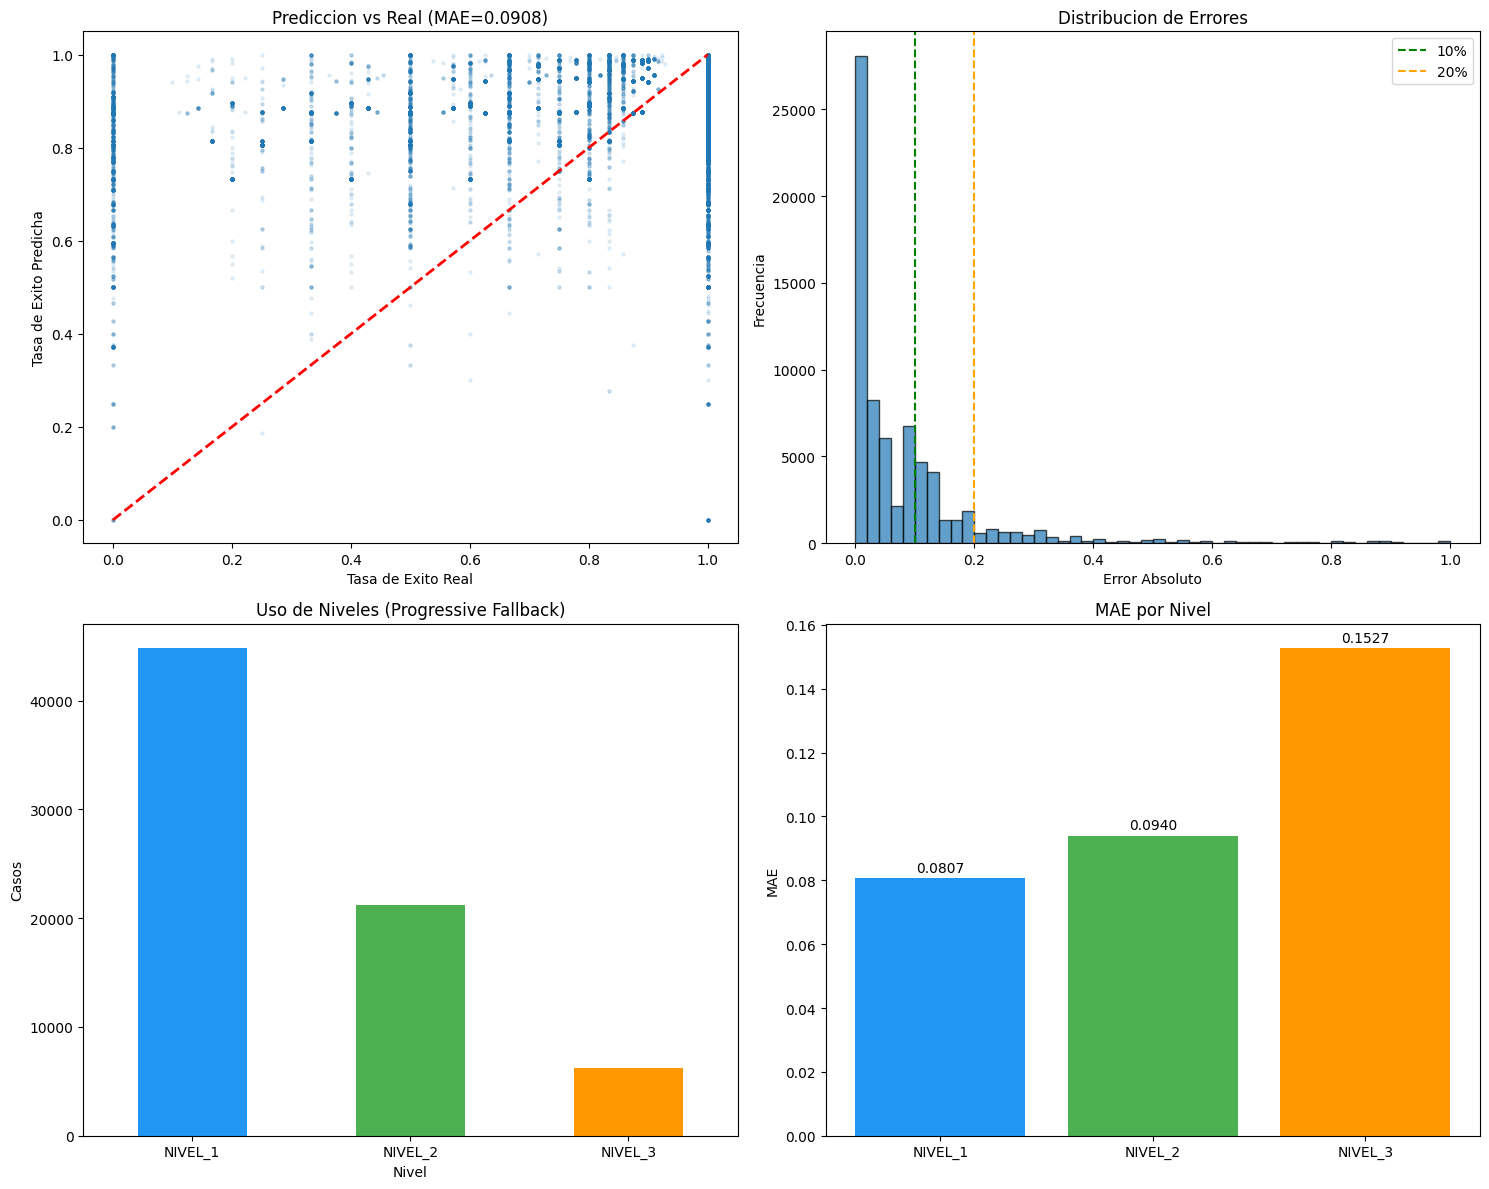

Visualizaciones guardadas en docs/LADA_v5_resultados.png


In [13]:
# ============================================================================
# VISUALIZACIONES
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Prediccion vs Real
ax = axes[0, 0]
ax.scatter(reales, predicciones, alpha=0.1, s=5)
ax.plot([0, 1], [0, 1], 'r--', linewidth=2)
ax.set_xlabel('Tasa de Exito Real')
ax.set_ylabel('Tasa de Exito Predicha')
ax.set_title(f'Prediccion vs Real (MAE={mae:.4f})')

# 2. Distribucion de errores
ax = axes[0, 1]
ax.hist(errores, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(x=0.10, color='g', linestyle='--', label='10%')
ax.axvline(x=0.20, color='orange', linestyle='--', label='20%')
ax.set_xlabel('Error Absoluto')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion de Errores')
ax.legend()

# 3. Uso de niveles
ax = axes[1, 0]
niveles_counts = pd.Series(niveles_usados).value_counts()
niveles_counts.plot(kind='bar', ax=ax, color=['#2196F3', '#4CAF50', '#FF9800'])
ax.set_xlabel('Nivel')
ax.set_ylabel('Casos')
ax.set_title('Uso de Niveles (Progressive Fallback)')
ax.tick_params(axis='x', rotation=0)

# 4. MAE por nivel
ax = axes[1, 1]
mae_por_nivel = {}
for nivel_nombre in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
    mask_n = np.array(niveles_usados) == nivel_nombre
    if mask_n.any():
        mae_por_nivel[nivel_nombre] = mean_absolute_error(reales[mask_n], predicciones[mask_n])
if mae_por_nivel:
    bars = ax.bar(mae_por_nivel.keys(), mae_por_nivel.values(), color=['#2196F3', '#4CAF50', '#FF9800'])
    ax.set_ylabel('MAE')
    ax.set_title('MAE por Nivel')
    for bar, val in zip(bars, mae_por_nivel.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.4f}', ha='center')

plt.tight_layout()
plt.savefig('../docs/LADA_v5_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualizaciones guardadas en docs/LADA_v5_resultados.png")

In [14]:

# ============================================================================
# RESUMEN DE SELECCION DE ALGORITMOS POR GRUPO LEVEL 1
# ============================================================================
print("SELECCION DE ALGORITMO POR GRUPO LEVEL 1 — RESUMEN")
print("=" * 70)
print(f"{'Cursos':>8} | {'Algoritmo':^10} | {'MAE_val':>8} | {'k':>3} | Hiperparametros clave")
print("-" * 70)
for nc in sorted(nivel1_best.keys(), key=lambda x: int(x)):
    cfg = nivel1_best[nc]
    if cfg['algo'] is None:
        print(f"  {nc:>6} | {'SKIP':^10} | {'—':>8} |")
        continue
    p = cfg['params']
    k = p.get('n_clusters', p.get('n_components', '?'))
    # Extra param
    if cfg['algo'] == 'fuzzy':
        extra = f"m={p.get('m')} err={p.get('error')}"
    elif cfg['algo'] == 'kmeans':
        extra = f"init={p.get('init')} n_init={p.get('n_init')}"
    else:
        extra = f"cov={p.get('covariance_type')} n_init={p.get('n_init')}"
    print(f"  {nc:>6} | {cfg['algo'].upper():^10} | {cfg['mae_val']:>8.4f} | {k:>3} | {extra}")

print("\nDistribución de algoritmos ganadores:")
algo_counts = {}
for cfg in nivel1_best.values():
    if cfg['algo']:
        algo_counts[cfg['algo']] = algo_counts.get(cfg['algo'], 0) + 1
for a, cnt in sorted(algo_counts.items(), key=lambda x: -x[1]):
    pct = cnt / len(nivel1_best) * 100
    print(f"  {a.upper():6s}: {cnt} grupos ({pct:.1f}%)")


SELECCION DE ALGORITMO POR GRUPO LEVEL 1 — RESUMEN
  Cursos | Algoritmo  |  MAE_val |   k | Hiperparametros clave
----------------------------------------------------------------------
       1 |    GMM     |   0.1158 |   5 | cov=diag n_init=1
       2 |    GMM     |   0.1256 |   4 | cov=full n_init=1
       3 |    GMM     |   0.0974 |   4 | cov=full n_init=3
       4 |    GMM     |   0.1304 |   4 | cov=full n_init=3
       5 |    GMM     |   0.0973 |   4 | cov=tied n_init=3
       6 |   FUZZY    |   0.0622 |   4 | m=1.5 err=0.005
       7 |    GMM     |   0.0473 |   4 | cov=full n_init=3
       8 |   KMEANS   |   0.0406 |   3 | init=k-means++ n_init=10
       9 |   FUZZY    |   0.0343 |   4 | m=2.0 err=0.01
      10 |    GMM     |   0.0270 |   4 | cov=full n_init=3
      11 |    GMM     |   0.0266 |   3 | cov=diag n_init=1
      12 |    GMM     |   0.0194 |   5 | cov=diag n_init=1
      13 |   FUZZY    |   0.0099 |   5 | m=2.5 err=0.005
      14 |    GMM     |   0.0112 |   2 | cov=ful

In [15]:

# ============================================================================
# EXPORTACION DEL MODELO
# ============================================================================
os.makedirs("../models_2", exist_ok=True)

modelo_lada = {
    "resultados_por_nivel": resultados_por_nivel,
    "nivel1_best": nivel1_best,           # config (algo+params) por grupo Level 1
    "scaler_nivel1": scaler_n1,           # scaler fitted en todos los datos de train
    "mapeo_curso_cat": mapeo_curso_cat,
    "FEATURE_COLS": FEATURE_COLS,
    "PARAM_SPACES": PARAM_SPACES,
    "usar_departamento_nivel2": usar_departamento_nivel2,
    "metricas_test": {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "Acc_10pct": float(acc_10),
        "Acc_20pct": float(acc_20),
        "Cobertura": float(cobertura),
        "n_test": len(predicciones),
        "n_test_total": len(test_firmas)
    },
    "version": "v5",
    "descripcion": (
        "Level 1 propagation: algoritmo+hiperparametros seleccionados por grupo de cursos "
        f"({len(nivel1_best)} grupos), propagados a NIVEL_2 y NIVEL_3. "
        f"Random Search: {N_ITER_SEARCH} iter x 3 algoritmos por grupo Level 1."
    )
}

ruta_modelo = "../models_2/lada_modelo_v5.pkl"
with open(ruta_modelo, "wb") as f:
    pickle.dump(modelo_lada, f)

print(f"Modelo guardado en: {ruta_modelo}")
print(f"Tamano: {os.path.getsize(ruta_modelo) / (1024*1024):.1f} MB")

# Resumen final
n_grupos = len(nivel1_best)
print(f"\n{'='*70}")
print(f"RESUMEN EJECUTIVO - LADA v5")
print(f"{'='*70}")
print(f"  Estrategia: Level 1 propagation (algo+params por grupo de cursos)")
print(f"  Random Search: {N_ITER_SEARCH} iter x 3 algoritmos x {n_grupos} grupos Level 1")
print(f"  MAE:         {mae:.4f}")
print(f"  Acc +/-10%:  {acc_10:.1f}%")
print(f"  Acc +/-20%:  {acc_20:.1f}%")
print(f"  Cobertura:   {cobertura:.1f}%")
print(f"  Test cases:  {len(predicciones):,}")


Modelo guardado en: ../models_2/lada_modelo_v5.pkl
Tamano: 1.6 MB

RESUMEN EJECUTIVO - LADA v5
  Estrategia: Level 1 propagation (algo+params por grupo de cursos)
  Random Search: 10 iter x 3 algoritmos x 14 grupos Level 1
  MAE:         0.0908
  Acc +/-10%:  71.1%
  Acc +/-20%:  89.5%
  Cobertura:   100.0%
  Test cases:  72,248
